engineer segmentation fields

C:\Users\chand\AppData\Local\Temp\ipykernel_20208\2670050205.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="region", y="is_return", data=region_returns, palette="coolwarm")


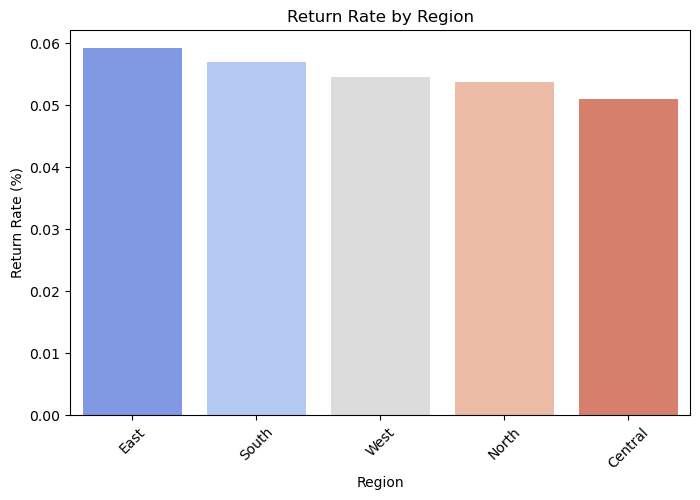

C:\Users\chand\AppData\Local\Temp\ipykernel_20208\2670050205.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="customer_segment", y="is_return", data=cust_segment_returns, palette="Set2")


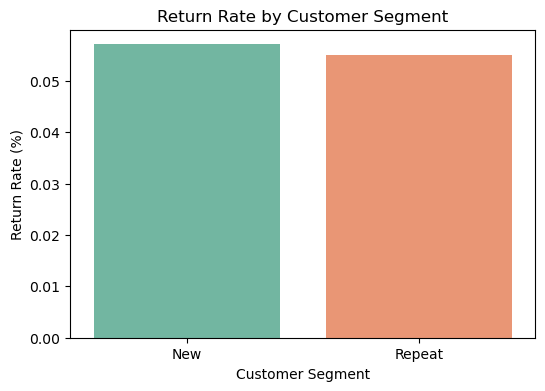

C:\Users\chand\AppData\Local\Temp\ipykernel_20208\2670050205.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("price_band")["is_return"]
C:\Users\chand\AppData\Local\Temp\ipykernel_20208\2670050205.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="price_band", y="is_return", data=price_band_returns, palette="plasma")


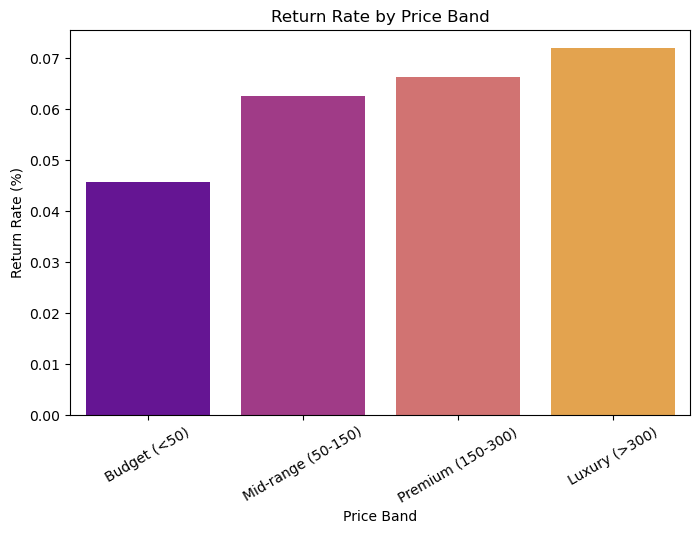

📊 Return Rate by Region:
     region  is_return
1     East   0.059096
3    South   0.056830
4     West   0.054495
2    North   0.053619
0  Central   0.050959

📊 Return Rate by Customer Segment:
   customer_segment  is_return
0              New   0.057064
1           Repeat   0.055008

📊 Return Rate by Price Band:
            price_band  is_return
3       Luxury (>300)   0.071869
2   Premium (150-300)   0.066219
1  Mid-range (50-150)   0.062557
0        Budget (<50)   0.045748


In [7]:
# Phase 3: Pattern Detection (fixed for Kaggle dataset)
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset from the workspace root or notebook folder.
workspace_root = Path.cwd()
data_path = workspace_root / "cleaned_ecommerce_returns.csv"
if not data_path.exists():
    data_path = workspace_root.parent / "cleaned_ecommerce_returns.csv"

df = pd.read_csv(data_path)

# --- 1. Return Rate by Region (Country) ---
region_returns = (
    df.groupby("region")["is_return"]
    .mean()
    .reset_index()
    .sort_values(by="is_return", ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(x="region", y="is_return", data=region_returns, palette="coolwarm")
plt.title("Return Rate by Region")
plt.ylabel("Return Rate (%)")
plt.xlabel("Region")
plt.xticks(rotation=45)
plt.show()

# --- 2. Return Rate by Customer Segment ---
# Create synthetic segmentation: New vs Repeat
# Define "New" if customer_id appears < 3 times, else "Repeat"
cust_counts = df["customer_id"].value_counts()
df["customer_segment"] = df["customer_id"].apply(lambda x: "New" if cust_counts[x] < 3 else "Repeat")

cust_segment_returns = (
    df.groupby("customer_segment")["is_return"]
    .mean()
    .reset_index()
    .sort_values(by="is_return", ascending=False)
)

plt.figure(figsize=(6,4))
sns.barplot(x="customer_segment", y="is_return", data=cust_segment_returns, palette="Set2")
plt.title("Return Rate by Customer Segment")
plt.ylabel("Return Rate (%)")
plt.xlabel("Customer Segment")
plt.show()

# --- 3. Return Rate by Price Band ---
bins = [0, 50, 150, 300, 500]
labels = ["Budget (<50)", "Mid-range (50-150)", "Premium (150-300)", "Luxury (>300)"]
df["price_band"] = pd.cut(df["price"], bins=bins, labels=labels, include_lowest=True)

price_band_returns = (
    df.groupby("price_band")["is_return"]
    .mean()
    .reset_index()
    .sort_values(by="is_return", ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(x="price_band", y="is_return", data=price_band_returns, palette="plasma")
plt.title("Return Rate by Price Band")
plt.ylabel("Return Rate (%)")
plt.xlabel("Price Band")
plt.xticks(rotation=30)
plt.show()

# --- 4. Summary Stats ---
print("📊 Return Rate by Region:\n", region_returns)
print("\n📊 Return Rate by Customer Segment:\n", cust_segment_returns)
print("\n📊 Return Rate by Price Band:\n", price_band_returns)